# Сравнение аннотаторов (мышь): IgBLAST vs abstar (200 reads)

Сравнение уже готовых smoke-аннотаций для мыши `ERP003950`, sample `ERR346596`, 200 merged sequences.

Оба аннотатора запускались с mouse-compatible germline DB:
- IgBLAST — `/data/user/epishkin/igblast/internal_data/mouse/mouse_gl_V/D/J`
- abstar — `c57bl6`

При каждом запуске notebook заново читает текущие TSV и перезаписывает `comparison_report_mouse.json`.


In [31]:
# CELL 1: Настройка
import csv, json
from pathlib import Path
from collections import Counter

DATASET = "ERP003950"
SAMPLE = "ERR346596"
N = 200
BASE = Path("/data/user/epishkin/results") / DATASET
COMPARE = BASE / "annotator_compare"

IG_TSV = COMPARE / "output" / "igblast" / f"{SAMPLE}_{N}_igblast.tsv"
AB_TSV = COMPARE / "output" / "abstar" / SAMPLE / "airr" / f"{SAMPLE}_{N}.tsv"
REPORT = COMPARE / "comparison_report_mouse.json"

print("DATASET:", DATASET)
print("SAMPLE:", SAMPLE)
print("IgBLAST:", IG_TSV, "exists=", IG_TSV.exists(), "size=", IG_TSV.stat().st_size if IG_TSV.exists() else None)
print("abstar: ", AB_TSV, "exists=", AB_TSV.exists(), "size=", AB_TSV.stat().st_size if AB_TSV.exists() else None)


DATASET: ERP003950
SAMPLE: ERR346596
IgBLAST: /data/user/epishkin/results/ERP003950/annotator_compare/output/igblast/ERR346596_200_igblast.tsv exists= True size= 642318
abstar:  /data/user/epishkin/results/ERP003950/annotator_compare/output/abstar/ERR346596/airr/ERR346596_200.tsv exists= True size= 2150722


In [33]:
# CELL 2: При необходимости — нормализовать существующие выходы в канонический layout annotator_compare
# Эта ячейка не перезапускает аннотацию. Она только чинит layout путей, если есть старая плоская локальная копия.

flat_ab = COMPARE / "output" / "abstar" / f"{SAMPLE}_{N}.tsv"
AB_TSV.parent.mkdir(parents=True, exist_ok=True)

if AB_TSV.exists() and AB_TSV.stat().st_size > 0:
    print("SKIP exists:", AB_TSV)
elif flat_ab.exists() and flat_ab.stat().st_size > 0:
    AB_TSV.write_bytes(flat_ab.read_bytes())
    print("COPIED:", flat_ab, "->", AB_TSV)
else:
    print("No flat abstar copy to normalize")

print("Final files:")
for p in [IG_TSV, AB_TSV]:
    print(p, "exists=", p.exists(), "size=", p.stat().st_size if p.exists() else None)


SKIP exists: /data/user/epishkin/results/ERP003950/annotator_compare/output/abstar/ERR346596/airr/ERR346596_200.tsv
Final files:
/data/user/epishkin/results/ERP003950/annotator_compare/output/igblast/ERR346596_200_igblast.tsv exists= True size= 642318
/data/user/epishkin/results/ERP003950/annotator_compare/output/abstar/ERR346596/airr/ERR346596_200.tsv exists= True size= 2150722


In [34]:
# CELL 3: Загрузка TSV и проверка общих sequence ID

def load_tsv(path):
    rows = {}
    with open(path, newline="") as f:
        reader = csv.DictReader(f, delimiter="	")
        for row in reader:
            rows[row["sequence_id"]] = row
    return rows

if not IG_TSV.exists():
    raise FileNotFoundError(f"IgBLAST TSV missing: {IG_TSV}")
if not AB_TSV.exists():
    raise FileNotFoundError(f"abstar TSV missing: {AB_TSV}")

igrows = load_tsv(IG_TSV)
abrows = load_tsv(AB_TSV)
shared = sorted(set(igrows) & set(abrows))

print(f"IgBLAST reads: {len(igrows)}")
print(f"abstar reads:  {len(abrows)}")
print(f"Shared reads:  {len(shared)}")
print("First 5 shared IDs:", shared[:5])


IgBLAST reads: 200
abstar reads:  198
Shared reads:  198
First 5 shared IDs: ['ERR346596.1005', 'ERR346596.1006', 'ERR346596.109', 'ERR346596.150', 'ERR346596.152']


In [35]:
# CELL 4: Сравнение productivity, V/D/J calls и CDR3 AA

def is_productive(row):
    return row.get("productive", "").strip().lower() in {"t", "true", "1", "yes"}

def pct(a, b):
    return round((a / b * 100), 1) if b else 0.0

ig_prod = sum(is_productive(r) for r in igrows.values())
ab_prod = sum(is_productive(r) for r in abrows.values())

stats = {
    "dataset": DATASET,
    "sample": SAMPLE,
    "reads_requested": N,
    "igblast": {"total": len(igrows), "productive": ig_prod, "productive_pct": pct(ig_prod, len(igrows)), "germline_db": "mouse_gl"},
    "abstar": {"total": len(abrows), "productive": ab_prod, "productive_pct": pct(ab_prod, len(abrows)), "germline_db": "c57bl6"},
    "shared_reads": len(shared),
}

for field in ["v_call", "d_call", "j_call", "cdr3_aa"]:
    agree = sum(igrows[s].get(field, "").strip() == abrows[s].get(field, "").strip() for s in shared)
    stats[field + "_agree"] = agree
    stats[field + "_agree_pct"] = pct(agree, len(shared))

print("Productive IgBLAST:", f"{ig_prod}/{len(igrows)}", f"({stats['igblast']['productive_pct']}%)")
print("Productive abstar: ", f"{ab_prod}/{len(abrows)}", f"({stats['abstar']['productive_pct']}%)")
print()
print(f"On {len(shared)} shared reads:")
for field in ["v_call", "d_call", "j_call", "cdr3_aa"]:
    print(f"  {field:8s}: {stats[field + '_agree']}/{len(shared)} ({stats[field + '_agree_pct']}%)")


Productive IgBLAST: 190/200 (95.0%)
Productive abstar:  189/198 (95.5%)

On 198 shared reads:
  v_call  : 0/198 (0.0%)
  d_call  : 4/198 (2.0%)
  j_call  : 0/198 (0.0%)
  cdr3_aa : 196/198 (99.0%)


In [37]:
# CELL 5: Распределения calls и первые примеры

def top_counts(rows, field, n=10):
    c = Counter((r.get(field, "") or "<EMPTY>").strip() or "<EMPTY>" for r in rows.values())
    return c.most_common(n)

print("Top IgBLAST V calls:")
for k, v in top_counts(igrows, "v_call"):
    print(f"  {v:3d}  {k}")

print("Top abstar V calls:")
for k, v in top_counts(abrows, "v_call"):
    print(f"  {v:3d}  {k}")

print("First 10 shared reads: IgBLAST -> abstar")
for sid in shared[:10]:
    print(f"{sid}")
    print("  V:", igrows[sid].get("v_call", ""), "->", abrows[sid].get("v_call", ""))
    print("  J:", igrows[sid].get("j_call", ""), "->", abrows[sid].get("j_call", ""))
    print("  CDR3_AA:", igrows[sid].get("cdr3_aa", ""), "->", abrows[sid].get("cdr3_aa", ""))


Top IgBLAST V calls:
   18  VHSM7.a3.93
   10  VH7183.a4.6,VHD6.96
    9  J558.83.189
    8  J558.54.148
    8  VHQ52.a27.79,VOx-1
    7  J558.29
    7  V11,VHS107.a3.106
    6  J558.33
    6  J558.47
    6  J558.19
Top abstar V calls:
   18  IGHV0-HCH3*00
   15  IGHV0-YQC3*00
   12  IGHV0-MUFD*00
   10  IGHV0-2CAX*00
   10  IGHV0-N4AL*00
    9  IGHV0-N7DC*00
    9  IGHV0-WECQ*00
    8  IGHV0-SFTO*00
    7  IGHV0-2DPF*00
    7  IGHV0-COSL*00
First 10 shared reads: IgBLAST -> abstar
ERR346596.1005
  V: VH50.1,VH7183.a13.20 -> IGHV0-MSJQ*00
  J: JH4 -> IGHJ0-TXGH*00
  CDR3_AA: ARGSLFYAMDY -> ARGSLFYAMDY
ERR346596.1006
  V: J558.19 -> IGHV0-2CAX*00
  J: JH1 -> IGHJ0-32C2*00
  CDR3_AA: ARGDYGYHWYFDV -> ARGDYGYHWYFDV
ERR346596.109
  V: VHSM7.a3.93 -> IGHV0-HCH3*00
  J: JH3 -> IGHJ0-OHJS*00
  CDR3_AA: AIYYYGSSGFAY -> AIYYYGSSGFAY
ERR346596.150
  V: VHA1 -> IGHV0-2DFB*00
  J: JH4 -> IGHJ0-TXGH*00
  CDR3_AA: ARNGNYRYAMDY -> ARNGNYRYAMDY
ERR346596.152
  V: VHQ52.a27.79,VOx-1 -> IGHV0-N4AL*00
  

In [38]:
# CELL 6: Сохранение JSON-отчёта
report = {
    **stats,
    "notes": [
        "Mouse comparison uses mouse-compatible germline DBs in both annotators.",
        "IgBLAST and abstar use different germline database nomenclatures, so V/D/J exact string agreement can be low even when annotations are biologically similar.",
        "CDR3_AA is the most portable direct comparison field across these annotators."
    ],
}
REPORT.parent.mkdir(parents=True, exist_ok=True)
REPORT.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")
print("WROTE:", REPORT)
print(json.dumps(report, indent=2, ensure_ascii=False))


WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/comparison_report_mouse.json
{
  "dataset": "ERP003950",
  "sample": "ERR346596",
  "reads_requested": 200,
  "igblast": {
    "total": 200,
    "productive": 190,
    "productive_pct": 95.0,
    "germline_db": "mouse_gl"
  },
  "abstar": {
    "total": 198,
    "productive": 189,
    "productive_pct": 95.5,
    "germline_db": "c57bl6"
  },
  "shared_reads": 198,
  "v_call_agree": 0,
  "v_call_agree_pct": 0.0,
  "d_call_agree": 4,
  "d_call_agree_pct": 2.0,
  "j_call_agree": 0,
  "j_call_agree_pct": 0.0,
  "cdr3_aa_agree": 196,
  "cdr3_aa_agree_pct": 99.0,
  "notes": [
    "Mouse comparison uses mouse-compatible germline DBs in both annotators.",
    "IgBLAST and abstar use different germline database nomenclatures, so V/D/J exact string agreement can be low even when annotations are biologically similar.",
    "CDR3_AA is the most portable direct comparison field across these annotators."
  ]
}


In [39]:
# CELL 7: Построение per-read таблицы сравнения
try:
    import pandas as pd
except ImportError as e:
    raise ImportError("pandas is required for visualization cells in this notebook") from e

def mismatch_category(ig_cdr3, ab_cdr3):
    ig_present = bool(ig_cdr3)
    ab_present = bool(ab_cdr3)
    if ig_present and ab_present and ig_cdr3 == ab_cdr3:
        return "match"
    if ig_present and ab_present and ig_cdr3 != ab_cdr3:
        return "both_present_different"
    if (not ig_present) and ab_present:
        return "igblast_missing_abstar_present"
    if ig_present and (not ab_present):
        return "igblast_present_abstar_missing"
    return "both_missing"

def to_float(x):
    try:
        if x is None or str(x).strip() == "":
            return None
        return float(x)
    except Exception:
        return None

rows = []
for sid in shared:
    ir = igrows[sid]
    ar = abrows[sid]
    ig_cdr3 = ir.get("cdr3_aa", "").strip()
    ab_cdr3 = ar.get("cdr3_aa", "").strip()
    rows.append({
        "sequence_id": sid,
        "ig_productive": is_productive(ir),
        "ab_productive": is_productive(ar),
        "ig_v_call": ir.get("v_call", "").strip(),
        "ab_v_call": ar.get("v_call", "").strip(),
        "ig_d_call": ir.get("d_call", "").strip(),
        "ab_d_call": ar.get("d_call", "").strip(),
        "ig_j_call": ir.get("j_call", "").strip(),
        "ab_j_call": ar.get("j_call", "").strip(),
        "ig_cdr3_aa": ig_cdr3,
        "ab_cdr3_aa": ab_cdr3,
        "cdr3_aa_match": ig_cdr3 == ab_cdr3,
        "cdr3_mismatch_category": mismatch_category(ig_cdr3, ab_cdr3),
        "ig_cdr3_len": len(ig_cdr3),
        "ab_cdr3_len": len(ab_cdr3),
        "ig_v_identity": to_float(ir.get("v_identity", "")),
        "ab_v_identity": to_float(ar.get("v_identity", "")),
    })

df = pd.DataFrame(rows)
TABLE = COMPARE / f"comparison_table_{SAMPLE}_{N}.tsv"
df.to_csv(TABLE, sep="\t", index=False)
print("WROTE:", TABLE)
print("Rows:", len(df))
print("CDR3 categories:")
print(df["cdr3_mismatch_category"].value_counts())
display(df.head(10))


WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/comparison_table_ERR346596_200.tsv
Rows: 198
CDR3 categories:
cdr3_mismatch_category
match                     196
both_present_different      2
Name: count, dtype: int64


,sequence_id,ig_productive,ab_productive,ig_v_call,ab_v_call,ig_d_call,ab_d_call,ig_j_call,ab_j_call,ig_cdr3_aa,ab_cdr3_aa,cdr3_aa_match,cdr3_mismatch_category,ig_cdr3_len,ab_cdr3_len,ig_v_identity,ab_v_identity
0,ERR346596.1005,True,True,"VH50.1,VH7183.a13.20",IGHV0-MSJQ*00,,IGHD0-4WOL*00__mus_musculus,JH4,IGHJ0-TXGH*00,ARGSLFYAMDY,ARGSLFYAMDY,True,match,11,11,98.980,0.986395
1,ERR346596.1006,True,True,J558.19,IGHV0-2CAX*00,DFL16.2,IGHD0-VHCZ*00__mus_musculus,JH1,IGHJ0-32C2*00,ARGDYGYHWYFDV,ARGDYGYHWYFDV,True,match,13,13,98.299,0.891156
2,ERR346596.109,True,True,VHSM7.a3.93,IGHV0-HCH3*00,DFL16.1,IGHD0-VHCZ*00,JH3,IGHJ0-OHJS*00,AIYYYGSSGFAY,AIYYYGSSGFAY,True,match,12,12,99.658,0.976027
3,ERR346596.150,True,True,VHA1,IGHV0-2DFB*00,"DSP2.5,DSP2.7,DSP2.8",IGHD0-W5WR*00,JH4,IGHJ0-TXGH*00,ARNGNYRYAMDY,ARNGNYRYAMDY,True,match,12,12,99.320,0.938776
4,ERR346596.152,True,True,"VHQ52.a27.79,VOx-1",IGHV0-N4AL*00,DFL16.2,IGHD0-VHCZ*00,JH2,IGHJ0-7IA7*00,ARYYYGFLDY,ARYYYGFLDY,True,match,10,10,98.621,0.965870
5,ERR346596.160,True,True,VHSM7.a4.108,IGHV0-XUCW*00,"DSP2.3,DSP2.4,DSP2.6",IGHD0-BTUW*00,JH3,IGHJ0-OHJS*00,NRGMVTTNAY,NRGMVTTNAY,True,match,10,10,95.189,0.938144
6,ERR346596.175,True,True,J558.54.148,IGHV0-WECQ*00,"DQ52-BALB/c,DQ52-C57BL/6",IGHD0-5S4H*00__mus_musculus,JH3,IGHJ0-OHJS*00,ARVLGRPF,ARVLGRPF,True,match,8,8,95.578,0.955782
7,ERR346596.187,True,True,J558.29,IGHV0-COSL*00,,,JH4,IGHJ0-TXGH*00,ARDTMDY,ARDTMDY,True,match,7,7,99.317,0.955782
8,ERR346596.189,True,True,VH36-60.a2.90,IGHV0-HOWM*00,DFL16.1,IGHD0-VHCZ*00,JH4,IGHJ0-TXGH*00,ARYDGSSYYAMDY,ARYDGSSYYAMDY,True,match,13,13,98.639,0.922297
9,ERR346596.194,True,True,VH36-60.a1.85,IGHV0-HOWM*00,DSP2.13,IGHD0-5S4H*00__mus_musculus,JH4,IGHJ0-TXGH*00,ARFAVTPYTMDY,ARFAVTPYTMDY,True,match,12,12,96.907,0.904762


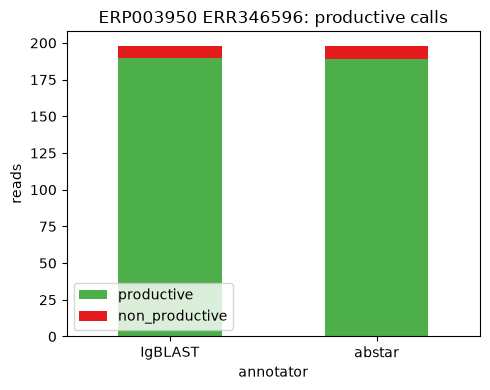

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_productive_calls.png


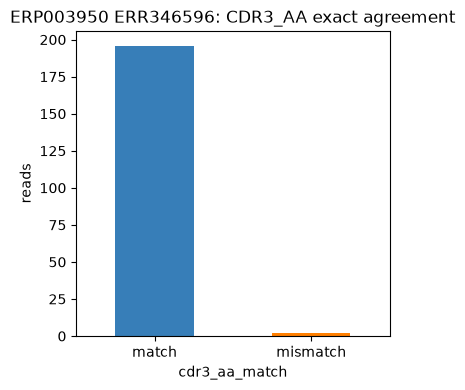

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_cdr3_aa_agreement.png


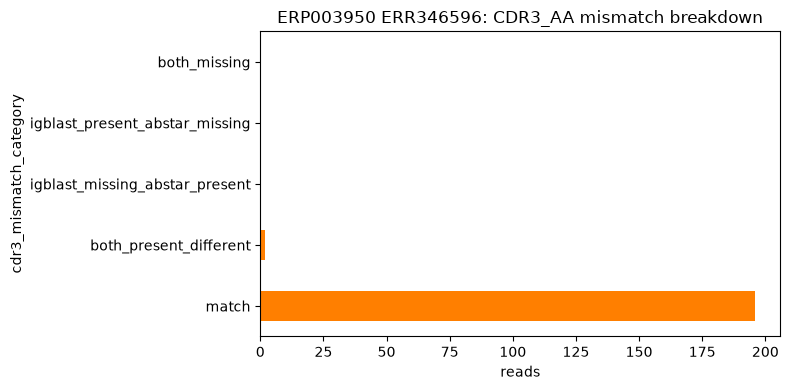

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_cdr3_mismatch_breakdown.png


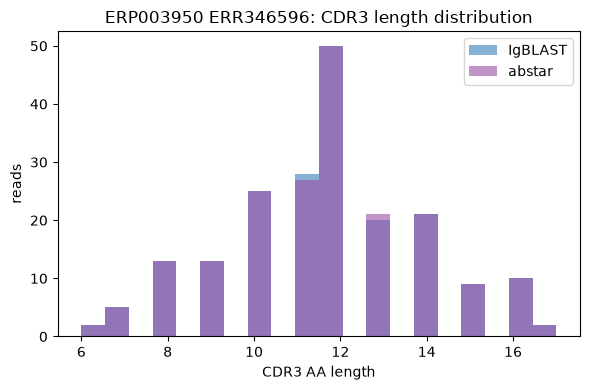

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_cdr3_length_distribution.png


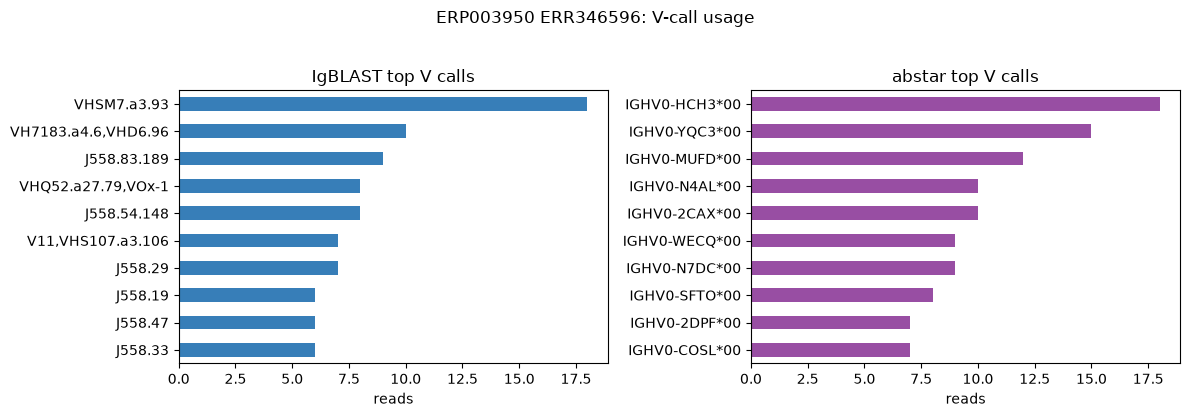

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_top_v_calls.png


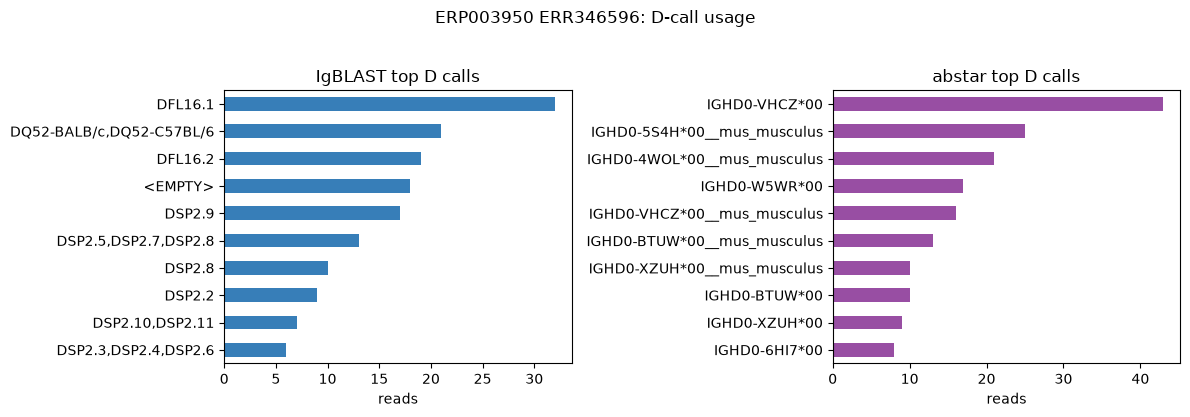

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_top_d_calls.png


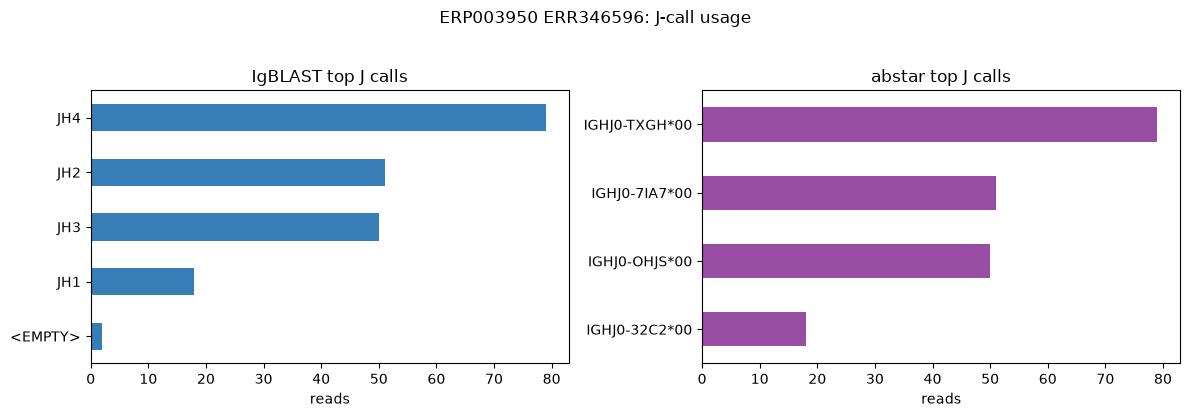

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_top_j_calls.png


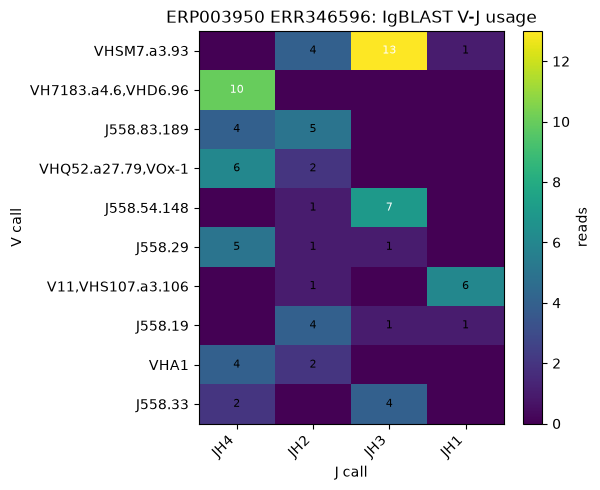

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_igblast_vj_heatmap.png


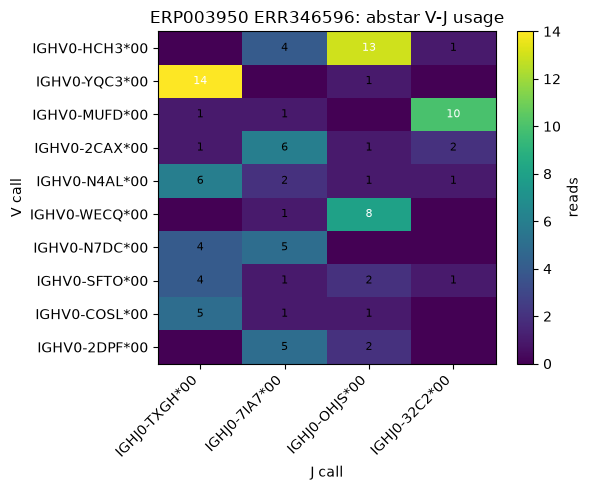

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_abstar_vj_heatmap.png


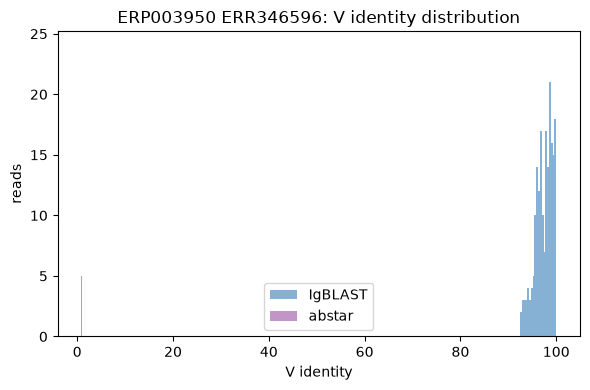

WROTE: /data/user/epishkin/results/ERP003950/annotator_compare/plots/ERR346596_200_v_identity_distribution.png


In [40]:
# CELL 8: Визуализация productive calls, CDR3 agreement, CDR3 length, V/D/J usage, V-J heatmaps и V identity
import matplotlib.pyplot as plt
import numpy as np

PLOTS = COMPARE / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

# 1) Stacked bar productive / non-productive
prod = pd.DataFrame({
    "annotator": ["IgBLAST", "abstar"],
    "productive": [int(df["ig_productive"].sum()), int(df["ab_productive"].sum())],
    "non_productive": [len(df) - int(df["ig_productive"].sum()), len(df) - int(df["ab_productive"].sum())],
}).set_index("annotator")

ax = prod[["productive", "non_productive"]].plot(kind="bar", stacked=True, figsize=(5, 4), color=["#4daf4a", "#e41a1c"])
ax.set_ylabel("reads")
ax.set_title(f"{DATASET} {SAMPLE}: productive calls")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
productive_png = PLOTS / f"{SAMPLE}_{N}_productive_calls.png"
plt.savefig(productive_png, dpi=160)
plt.show()
print("WROTE:", productive_png)

# 2) Bar точного совпадения CDR3_AA
agreement_counts = df["cdr3_aa_match"].map({True: "match", False: "mismatch"}).value_counts().reindex(["match", "mismatch"], fill_value=0)
ax = agreement_counts.plot(kind="bar", figsize=(4, 4), color=["#377eb8", "#ff7f00"])
ax.set_ylabel("reads")
ax.set_title(f"{DATASET} {SAMPLE}: CDR3_AA exact agreement")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
agreement_png = PLOTS / f"{SAMPLE}_{N}_cdr3_aa_agreement.png"
plt.savefig(agreement_png, dpi=160)
plt.show()
print("WROTE:", agreement_png)

# 3) Разбивка CDR3 mismatch: отличает настоящие расхождения последовательностей от отсутствующих calls
category_order = [
    "match",
    "both_present_different",
    "igblast_missing_abstar_present",
    "igblast_present_abstar_missing",
    "both_missing",
]
category_counts = df["cdr3_mismatch_category"].value_counts().reindex(category_order, fill_value=0)
ax = category_counts.plot(kind="barh", figsize=(8, 4), color="#ff7f00")
ax.set_xlabel("reads")
ax.set_title(f"{DATASET} {SAMPLE}: CDR3_AA mismatch breakdown")
plt.tight_layout()
mismatch_png = PLOTS / f"{SAMPLE}_{N}_cdr3_mismatch_breakdown.png"
plt.savefig(mismatch_png, dpi=160, bbox_inches="tight")
plt.show()
print("WROTE:", mismatch_png)

# 4) Наложение распределений длины CDR3 AA
plt.figure(figsize=(6, 4))
plt.hist(df["ig_cdr3_len"], bins=20, alpha=0.6, label="IgBLAST", color="#377eb8")
plt.hist(df["ab_cdr3_len"], bins=20, alpha=0.6, label="abstar", color="#984ea3")
plt.xlabel("CDR3 AA length")
plt.ylabel("reads")
plt.title(f"{DATASET} {SAMPLE}: CDR3 length distribution")
plt.legend()
plt.tight_layout()
cdr3_len_png = PLOTS / f"{SAMPLE}_{N}_cdr3_length_distribution.png"
plt.savefig(cdr3_len_png, dpi=160)
plt.show()
print("WROTE:", cdr3_len_png)

# 5) Top V-call usage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series([r.get("v_call", "").strip() or "<EMPTY>" for r in igrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[0], title="IgBLAST top V calls", color="#377eb8"
)
pd.Series([r.get("v_call", "").strip() or "<EMPTY>" for r in abrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[1], title="abstar top V calls", color="#984ea3"
)
for ax in axes:
    ax.set_xlabel("reads")
plt.suptitle(f"{DATASET} {SAMPLE}: V-call usage", y=1.03)
plt.tight_layout()
v_usage_png = PLOTS / f"{SAMPLE}_{N}_top_v_calls.png"
plt.savefig(v_usage_png, dpi=160, bbox_inches="tight")
plt.show()
print("WROTE:", v_usage_png)

# 6) Top D-call usage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series([r.get("d_call", "").strip() or "<EMPTY>" for r in igrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[0], title="IgBLAST top D calls", color="#377eb8"
)
pd.Series([r.get("d_call", "").strip() or "<EMPTY>" for r in abrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[1], title="abstar top D calls", color="#984ea3"
)
for ax in axes:
    ax.set_xlabel("reads")
plt.suptitle(f"{DATASET} {SAMPLE}: D-call usage", y=1.03)
plt.tight_layout()
d_usage_png = PLOTS / f"{SAMPLE}_{N}_top_d_calls.png"
plt.savefig(d_usage_png, dpi=160, bbox_inches="tight")
plt.show()
print("WROTE:", d_usage_png)

# 7) Top J-call usage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series([r.get("j_call", "").strip() or "<EMPTY>" for r in igrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[0], title="IgBLAST top J calls", color="#377eb8"
)
pd.Series([r.get("j_call", "").strip() or "<EMPTY>" for r in abrows.values()]).value_counts().head(10).sort_values().plot(
    kind="barh", ax=axes[1], title="abstar top J calls", color="#984ea3"
)
for ax in axes:
    ax.set_xlabel("reads")
plt.suptitle(f"{DATASET} {SAMPLE}: J-call usage", y=1.03)
plt.tight_layout()
j_usage_png = PLOTS / f"{SAMPLE}_{N}_top_j_calls.png"
plt.savefig(j_usage_png, dpi=160, bbox_inches="tight")
plt.show()
print("WROTE:", j_usage_png)

# 8) V-J usage heatmaps для каждого annotator (top V x top J, per annotator)
def plot_vj_heatmap(df, v_col, j_col, title, out_png):
    tmp = df[[v_col, j_col]].copy()
    tmp[v_col] = tmp[v_col].replace("", "<EMPTY>").fillna("<EMPTY>")
    tmp[j_col] = tmp[j_col].replace("", "<EMPTY>").fillna("<EMPTY>")
    top_v = tmp[v_col].value_counts().head(10).index
    top_j = tmp[j_col].value_counts().head(10).index
    mat = pd.crosstab(tmp[v_col], tmp[j_col]).reindex(index=top_v, columns=top_j, fill_value=0)
    fig, ax = plt.subplots(figsize=(max(6, 0.55 * len(top_j)), max(5, 0.35 * len(top_v))))
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)
    ax.set_xlabel("J call")
    ax.set_ylabel("V call")
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = int(mat.values[i, j])
            if val:
                ax.text(j, i, str(val), ha="center", va="center", color="white" if val > mat.values.max()/2 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label="reads")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160, bbox_inches="tight")
    plt.show()
    print("WROTE:", out_png)

plot_vj_heatmap(df, "ig_v_call", "ig_j_call", f"{DATASET} {SAMPLE}: IgBLAST V-J usage", PLOTS / f"{SAMPLE}_{N}_igblast_vj_heatmap.png")
plot_vj_heatmap(df, "ab_v_call", "ab_j_call", f"{DATASET} {SAMPLE}: abstar V-J usage", PLOTS / f"{SAMPLE}_{N}_abstar_vj_heatmap.png")

# 9) Распределение V identity, если есть
if df[["ig_v_identity", "ab_v_identity"]].notna().any().any():
    plt.figure(figsize=(6, 4))
    if df["ig_v_identity"].notna().any():
        plt.hist(df["ig_v_identity"].dropna(), bins=20, alpha=0.6, label="IgBLAST", color="#377eb8")
    if df["ab_v_identity"].notna().any():
        plt.hist(df["ab_v_identity"].dropna(), bins=20, alpha=0.6, label="abstar", color="#984ea3")
    plt.xlabel("V identity")
    plt.ylabel("reads")
    plt.title(f"{DATASET} {SAMPLE}: V identity distribution")
    plt.legend()
    plt.tight_layout()
    v_identity_png = PLOTS / f"{SAMPLE}_{N}_v_identity_distribution.png"
    plt.savefig(v_identity_png, dpi=160)
    plt.show()
    print("WROTE:", v_identity_png)
else:
    print("SKIP V identity distribution: no numeric v_identity values found in either annotator output")
